# 🌊 Wave & Winds Hindcast (1980-2023)

This is an exemplary notebook on how to use the Waves and Wind data for North Carolina, including Duck Beach.

### Dataset Characteristics

- **Temporal coverage**: Hourly data from 1980-2023
- **Spatial resolution**: ranges from approximately ~7km offshore to 3km nearshore, reaching 500m at 10m water depth.

### Available Variables

**23 variables** are available for the entire North Carolina, including:

- **Main bulk parameters**: `Hs`, `Tp`, `Tm02`, `Dirm`, `Dirp`
- **Winds**: `uwind`, `vwind`
- **Wave partitions**: Sea and three swells for directional wave spectrum reconstruction

### Model Information

- **WHACS waves** were downscaled using **BinWaves** (Cagigal et al., 2024) an additive hybrid method to downscale directional wave spectra to nearshore areas.

- **BinWaves model validation** with available wave buoys can be observed on the [ShoreShop3 website](https://shoreshop3.netlify.app/data) for each wave buoy:

![BinWaves Model Validation](./assets/hindcast_validation.png)

---

#### Before You Start

Make sure you have:

1. **Created and activated a Python environment**:
   ```bash
   conda activate my-env
   ```

2. **Installed the latest version of `bluemath-tk`**:
   ```bash
   pip install bluemath-tk
   ```

3. **Installed additional required libraries**:  
   This notebook requires Python libraries not present in `bluemath-tk`. Once your environment has been activated, install:
   ```bash
   pip install wavespectra
   ```

**For more information**, visit the **BlueMath Toolkit Repository**:  
   [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

---

> ⚠️ **IMPORTANT: Data Download Required**  
> 
> To run this Notebook, you must first download the variables of interest:
> 
> - **Download location**: [https://shoreshop3.netlify.app/data](https://shoreshop3.netlify.app/data) (use the download button)
> - **Save files in**: `./hindcast_1980_2023/inputs/waves&winds`
> 
> **Download options:**
> 
> - **Full dataset for North Carolina** (includes bulk parameters and partitions for directional wave spectrum reconstruction):  
>   Available variables for the entire North Carolina region:  
>   
>   **Bulk parameters:** `Hs`, `Tp`, `Tm02`, `Dp`, `Dm`  
>   
>   **Partitions** (sea and three swells):
>   - **Hs**: `phs0` (sea), `phs1`, `phs2`, `phs3`
>   - **Tp**: `ptp0` (sea), `ptp1`, `ptp2`, `ptp3`
>   - **Dp**: `dp0` (sea), `dp1`, `dp2`, `dp3`
>   - **Directional spreading**: `spr0` (sea), `spr1`, `spr2`, `spr3`
>   
>   **Winds (WHACS):** `uwnd`, `vwnd`
> 
> - **Duck Beach area only** (essential bulk parameters):  
>   Download the Duck file which contains the essential bulk parameters: `Hs`, `Tp`, and `Dp`.

---


## Entire North Carolina Coast

![alt text](/home/grupos/geocean/montanoj/shoreshop3-1/hindcast_1980_2023/assets/hindcast_domain.png)

### Time-series adquisitions(Bulk parameters)

You can get the entire time-series or any desired variable (19 in total), either using the ID, displayed in the portal or by coordinate. If there is a wave buoy nearby (less than 5km) comparison plots can be obtained. Time series can be saved in csv files to be used in other programing languages if need as for instance Matlab.

In [11]:
# Available Wave Buoys North Carolina
# Wave buoy data were obtained from the NDBC (National Data Buoy Center)
buoys = {
    'SSBN7': (-78.484, 33.838),
    '41119': (-78.483, 33.842),
    'OCPN7': (-78.147, 33.911),
    '41108': (-78.016, 33.721), 
    '41013': (-77.764, 33.441),
    '41110': (-77.715, 34.142),
    '41109': (-77.300, 34.484),
    '41035': (-77.281, 34.476),
    '41036': (-76.949, 34.207),
    '41159': (-76.944, 34.211),
    '41007': (-76.5, 34.2),
    
    'jprn7': (-75.5870, 35.9120),
    '41017': (-75.1000, 35.4000),
    '41015': (-75.3000, 35.4000),
    '41120': (-75.2580, 35.2580),
    'dsln7': (-75.2970, 35.1530),
    '41025': (-75.4540, 35.0100),
    '44095': (-75.3300, 35.7500),
    '44086': (-75.3300, 35.7500),

    '44006': (-75.4000, 36.3000),
    '44079': (-75.5930, 36.1750),
    '44056': (-75.7140, 36.2000),
    '44100': (-75.5930, 36.2580),
    '44019': (-75.2000, 36.4000),
    '44014':(-74.837, 36.603),
    '44088': (-74.839, 36.612),

}

In [ ]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.plotting import haversine_km

# =========================== user choices ===========================
# variables you want in the dataframe
variables = ["hs", "tp", "tm02","dp","dm"]  # e.g. ["hs", "tp", "tm02"]

# point of interest
point_lat = 36.2000
point_lon = -75.7140

# output paths
outputs_dir = "./outputs"
figures_dir = os.path.join(outputs_dir, "Figures")
os.makedirs(figures_dir, exist_ok=True)

# csv export
save_csv = True
csv_path = os.path.join(outputs_dir, f"hindcast__lon{point_lon:.4f}_lat{point_lat:.4f}.csv")

# buoy comparison
use_buoy = True         # set False to disable comparison
compare_vars = ["hs", "tp", "dp"]  # variables to compare with buoy
max_distance_km = 5.0

waves_base = "./inputs/waves&winds"

# ==========================================================================


def nc_path(var):
    return os.path.join(waves_base, f"{var}_NorthCarolina.nc")

variables = [v for v in variables if os.path.exists(nc_path(v))]
if not variables:
    raise ValueError("No valid variables selected.")

# load hindcast and build dataframe for first variable (to get site index and time axis)
first_var = variables[0]
first_ds = xr.open_dataset(nc_path(first_var))

lats = first_ds["lat"].values
lons = first_ds["lon"].values

site_dist = haversine_km(point_lat, point_lon, lats, lons)
site_idx = np.argmin(site_dist)

# build dataframe with all requested variables at that site
pt_df_list = []
for v in variables:
    with xr.open_dataset(nc_path(v)) as ds_v:
        pt_v = ds_v.isel(site=site_idx)[[v]]  
        pt_v = pt_v.load()  
        df_v = pt_v.to_dataframe().reset_index()[["time", v]]
        pt_df_list.append(df_v)

pt_df = pt_df_list[0]
for df_v in pt_df_list[1:]:
    pt_df = pt_df.merge(df_v, on="time", how="inner")

if save_csv:
    pt_df.to_csv(csv_path, index=False)
    print(f"Saved CSV to {csv_path}")

# direction-like variables to plot as points
direction_vars = {"dp", "dm", "dp0", "dp1", "dp2", "dp3", "spr0", "spr1", "spr2", "spr3"}

# plot hindcast time series and save figures
for v in variables:
    fig, ax = plt.subplots(figsize=(10, 3))
    if v in direction_vars:
        ax.plot(pt_df["time"], pt_df[v], linestyle="none", marker=".", color="k", markersize=0.5, label=f"Binwaves Hindcast {v}")
    else:
        ax.plot(pt_df["time"], pt_df[v], color="k", linewidth=0.5, label=f"Binwaves Hindcast {v}")
    ax.set_xlabel("Time")
    ax.set_ylabel(v)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(
        os.path.join(
            figures_dir,
            f"hindcast_{v}_lon{point_lon:.4f}_lat{point_lat:.4f}.png",
        ),
        dpi=150,
    )

# optional buoy comparison (only if near wave buoy)
if use_buoy:
    # find nearest buoy automatically
    buoy_ids = list(buoys.keys())
    buoy_lats = np.array([buoys[b][1] for b in buoy_ids])
    buoy_lons = np.array([buoys[b][0] for b in buoy_ids])

    buoy_dist = haversine_km(point_lat, point_lon, buoy_lats, buoy_lons)
    j = np.argmin(buoy_dist)
    nearest_buoy_id = buoy_ids[j]
    nearest_dist = float(buoy_dist[j])

    if nearest_dist <= max_distance_km:
        print(f"Nearest buoy: {nearest_buoy_id} at {nearest_dist:.2f} km")

        # Load NetCDF file and select specific buoy
        buoy_ds = xr.open_dataset("./inputs/buoys&tideGauges/buoy_data_all.nc")
        # Select buoy (handle case-insensitive matching)
        buoy_id_match = None
        for bid in buoy_ds.buoy_id.values:
            if str(bid).upper() == str(nearest_buoy_id).upper():
                buoy_id_match = str(bid)
                break
        if buoy_id_match is None:
            buoy_id_match = str(nearest_buoy_id)
        buoy_ds_sel = buoy_ds.sel(buoy_id=buoy_id_match)
        buoy_df = buoy_ds_sel.to_dataframe()
        buoy_df = buoy_df.reset_index()
        buoy_ds.close()

        def _coerce_time(series):
            if np.issubdtype(series.dtype, np.datetime64):
                return pd.to_datetime(series)
            if np.issubdtype(series.dtype, np.number):
                sample = pd.Series(series).dropna()
                if not sample.empty:
                    v = float(sample.iloc[0])
                    if v > 1e14:
                        unit = "ns"
                    elif v > 1e11:
                        unit = "ms"
                    else:
                        unit = "s"
                    return pd.to_datetime(series, unit=unit, errors="coerce")
            return pd.to_datetime(series, errors="coerce")

        pt_df["time"] = _coerce_time(pt_df["time"])
        buoy_df["time"] = _coerce_time(buoy_df["time"])

        # build merged data for selected comparison variables
        # Map hindcast variables to buoy column names
        var_to_buoy = {
            "hs": "Hs_Buoy",
            "tp": "Tp_Buoy",
            "dp": "Dir_Buoy",
            "dm": "Dir_Buoy",
            "tm02": "Tm_Buoy"
        }

        merged_map = {}
        for v in compare_vars:
            if v not in variables:
                continue

            buoy_var_col = var_to_buoy.get(v)
            if buoy_var_col is None or buoy_var_col not in buoy_df.columns:
                continue

            m = pd.merge(
                pt_df[["time", v]].rename(columns={v: "hindcast"}),
                buoy_df[["time", buoy_var_col]].rename(columns={buoy_var_col: "buoy"}),
                on="time",
                how="inner",
            )
            if not m.empty:
                merged_map[v] = m

        if merged_map:
            # time series: N x 1 subplots on common periods per variable
            n = len(merged_map)
            fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=True)
            if n == 1:
                axes = [axes]
            
            for ax, (v, m) in zip(axes, merged_map.items()):
                if v in direction_vars:
                    ax.plot(
                        m["time"],
                        m["hindcast"],
                        linestyle="none",
                        marker=".",
                        color="k",
                        label="Binwaves Hindcast",
                        markersize=0.5,
                    )
                    ax.plot(
                        m["time"],
                        m["buoy"],
                        linestyle="none",
                        marker=".",
                        color="mediumslateblue",
                        label="Buoy",
                        markersize=0.5,
                    )
                else:
                    ax.plot(m["time"], m["hindcast"], color="k", linewidth=0.5, label="Binwaves Hindcast")
                    ax.plot(
                        m["time"],
                        m["buoy"],
                        color="mediumslateblue",
                        label="Buoy",
                        alpha=0.9,
                    )
                ax.set_xlabel("Time")
                ax.set_ylabel(v)
                ax.legend()
                ax.grid(True, alpha=0.3)
        
            plt.tight_layout()
            
        
            fig.savefig(
                os.path.join(
                    figures_dir,
                    f"timeseries_comparison_{nearest_buoy_id}_lon{point_lon:.4f}_lat{point_lat:.4f}.png",
                ),
                dpi=150,
            )
        else:
            print("No overlapping time period between hindcast and buoy for selected variables.")
   

### Directional Wave Spectrum Reconstruction Using Wave Partitions

In [1]:
import numpy as np
import xarray as xr
from wavespectra.construct import construct_partition

# For a single month: time_to_sample = "2020-01"
time_to_sample = slice("1980", "2023")  # Change this to the period you want
seapoint_to_sample = 1669


def load_partition_series(file_prefix, data_var):
    parts = []
    for i in range(4):
        with xr.open_dataset(f"inputs/waves&winds/{file_prefix}{i}_NorthCarolina.nc") as ds:
            ds = ds.sel(time=time_to_sample, site=seapoint_to_sample)
            ds = ds.load()  # load data into memory to avoid HDF errors
            ds = ds.expand_dims({"part": [i]})
            parts.append(ds)

    combined = xr.concat(parts, dim="part")

    # Ensure unique, sorted time index to avoid alignment errors
    time_index = combined.indexes.get("time")
    if time_index is not None and not time_index.is_unique:
        _, unique_idx = np.unique(combined["time"].values, return_index=True)
        combined = combined.isel(time=np.sort(unique_idx))
    else:
        combined = combined.sortby("time")

    # Drop lon/lat coordinates to avoid merge conflicts
    combined = combined.drop_vars(["lon", "lat"], errors="ignore")
    return combined[data_var]


binwaves_sample = xr.Dataset(
    {
        "hs": load_partition_series("phs", "hs"),
        "tp": load_partition_series("ptp", "tp"),
        "dp": load_partition_series("dp", "dp"),
        "spr": load_partition_series("spr", "spr"),
    }
)
binwaves_sample

<xarray.Dataset> Size: 28MB
Dimensions:  (part: 4, time: 385714)
Coordinates:
  * part     (part) int64 32B 0 1 2 3
  * time     (time) datetime64[ns] 3MB 1980-01-01 ... 2023-12-31T23:00:00
    site     int64 8B 1669
Data variables:
    hs       (part, time) float32 6MB 0.896 0.9297 0.9585 ... 0.09562 0.1066
    tp       (part, time) float32 6MB 4.828 5.003 4.965 ... 8.516 6.691 7.005
    dp       (part, time) float32 6MB 35.48 38.26 39.4 ... 81.68 47.19 51.93
    spr      (part, time) float32 6MB 21.09 21.41 21.65 ... 24.04 15.35 23.3

In [2]:
dir = np.arange(0, 360, 5)
freq = np.logspace(np.log10(0.035), np.log10(0.5), 29)
full_spec = construct_partition(
    freq_name="jonswap",
    freq_kwargs={
        "freq": freq,
        "fp": 1 / binwaves_sample.tp,
        "hs": binwaves_sample.hs,
    },
    dir_name="cartwright",
    dir_kwargs={
        "dir": dir,
        "dm": binwaves_sample.dp,
        "dspr": binwaves_sample.spr,
    },
)
full_spec

<xarray.DataArray (part: 4, time: 385714, freq: 29, dir: 72)> Size: 26GB
array([[[[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [3.83749539e-311, 5.47575742e-311, 7.38559149e-311, ...,
          9.27001451e-312, 1.58198180e-311, 2.53837402e-311],
         ...,
         [1.11441758e-004, 1.59017268e-004, 2.14479293e-004, ...,
          2.69203375e-005, 4.59411192e-005, 7.37149712e-005],
         [7.10587087e-005, 1.01394324e-004, 1.36758625e-004, ...,
          1.71652391e-005, 2.92934773e-005, 4.70029437e-005],
         [4.49544374e-005, 6.41458996e-005, 8.65186995e-005, ...,
          1.08593821e-005, 1.85321661e-005, 2.97358470e-005]],

        [[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [5.61663422e-270, 8.17301864e-270, 1.12533779e-269, ...,
          1.28588500e-270, 2.23240151e-270, 3.64651179e-270],
...
          4.65560572e-010, 1.78667078e-009, 6.00442879e-009],
         [1.11301328e-008, 2.91691042e-008, 6.79676648e-008, ...,
          2.91522528e-010, 1.11876910e-009, 3.75982496e-009],
         [6.95457669e-009, 1.82260873e-008, 4.24690652e-008, ...,
          1.82155578e-010, 6.99054147e-010, 2.34929731e-009]],

        [[1.62057275e-152, 2.52998120e-152, 3.75632676e-152, ...,
          3.08172772e-153, 5.67068688e-153, 9.85195438e-153],
         [3.10812439e-105, 4.85229453e-105, 7.20432379e-105, ...,
          5.91049866e-106, 1.08759080e-105, 1.88952330e-105],
         [5.82956543e-073, 9.10091260e-073, 1.35123540e-072, ...,
          1.10856692e-073, 2.03987388e-073, 3.54397004e-073],
         ...,
         [1.23092597e-007, 1.92167834e-007, 2.85316420e-007, ...,
          2.34076419e-008, 4.30723997e-008, 7.48317314e-008],
         [7.69904777e-008, 1.20194827e-007, 1.78456284e-007, ...,
          1.46407305e-008, 2.69404068e-008, 4.68048518e-008],
         [4.80697275e-008, 7.50447686e-008, 1.11420856e-007, ...,
          9.14107753e-009, 1.68204959e-008, 2.92230486e-008]]]],
      shape=(4, 385714, 29, 72))
Coordinates:
  * part     (part) int64 32B 0 1 2 3
  * time     (time) datetime64[ns] 3MB 1980-01-01 ... 2023-12-31T23:00:00
    site     int64 8B 1669
  * freq     (freq) float64 232B 0.035 0.03849 0.04232 ... 0.4135 0.4547 0.5
  * dir      (dir) int64 576B 0 5 10 15 20 25 30 ... 325 330 335 340 345 350 355

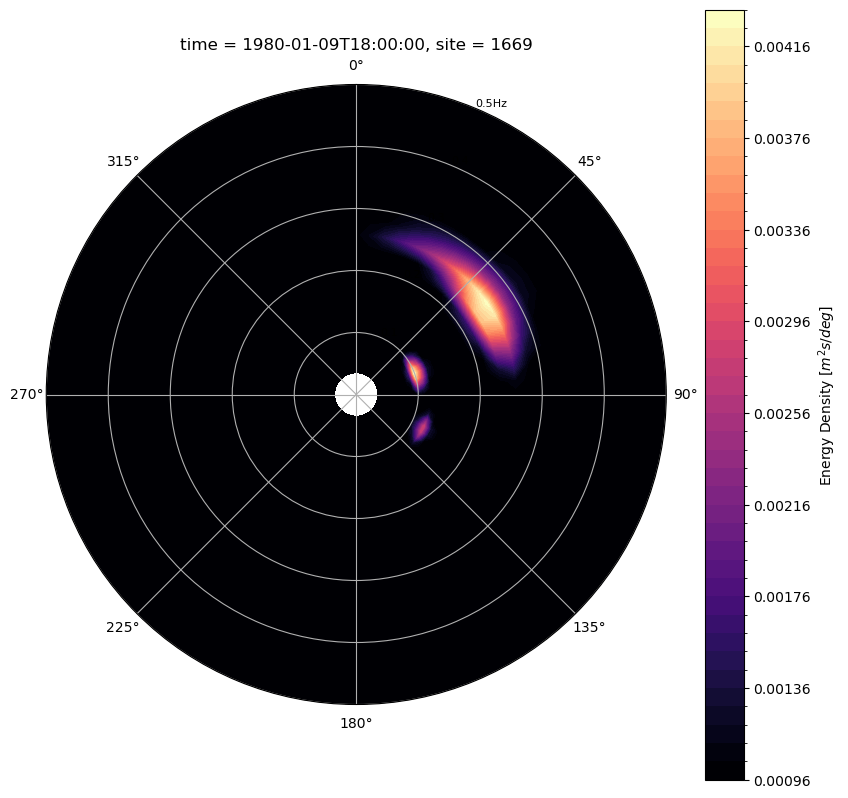

In [9]:
import wavespectra as ws
spec_total = full_spec.sum("part")

spec_total.isel(time=210).spec.plot(
    kind="contourf",
    cmap="magma",
    normalised=False,
    logradius=False,
    rmin=0,
    rmax=0.5,
    show_theta_labels=True,
    show_radii_labels=True,
    figsize=(10, 10),
    levels=50,  
)

### Wave buoy comparison with reconstructed directional wave spectrum

Nearest buoy: 44056 at 0.00 km


/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in subtract
  return self.func(*new_argspec)
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/home/grupos/geocean/montanoj/miniforge3/envs/bluemath-fork/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, *

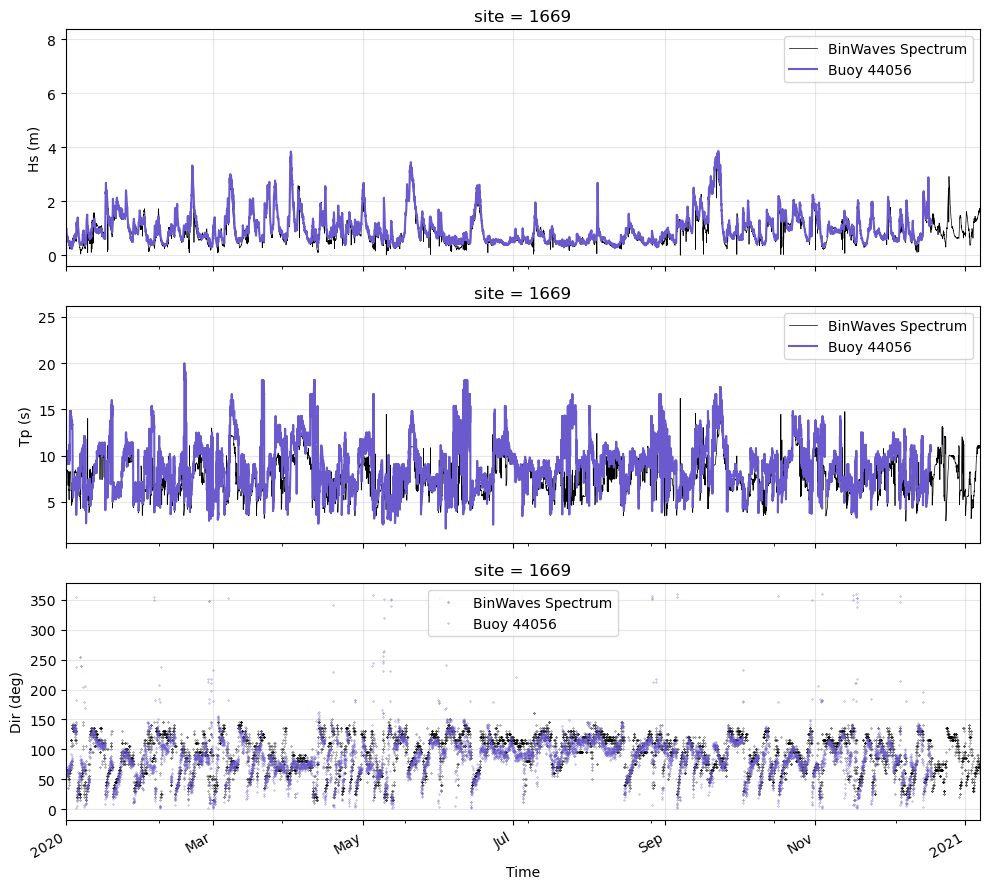

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.plotting import haversine_km

# point of interest
point_lat = 36.2000
point_lon = -75.7140

use_buoy = True
max_distance_km = 5.0
if use_buoy:
    # find nearest buoy automatically
    buoy_ids = list(buoys.keys())
    buoy_lats = np.array([buoys[b][1] for b in buoy_ids])
    buoy_lons = np.array([buoys[b][0] for b in buoy_ids])

    buoy_dist = haversine_km(point_lat, point_lon, buoy_lats, buoy_lons)
    j = np.argmin(buoy_dist)
    nearest_buoy_id = buoy_ids[j]
    nearest_dist = float(buoy_dist[j])

    if nearest_dist <= max_distance_km:
        print(f"Nearest buoy: {nearest_buoy_id} at {nearest_dist:.2f} km")

        # Load NetCDF file and select specific buoy
        buoy_ds = xr.open_dataset("./inputs/buoys&tideGauges/buoy_data_all.nc")
        # Select buoy (handle case-insensitive matching)
        buoy_id_match = None
        for bid in buoy_ds.buoy_id.values:
            if str(bid).upper() == str(nearest_buoy_id).upper():
                buoy_id_match = str(bid)
                break
        if buoy_id_match is None:
            buoy_id_match = str(nearest_buoy_id)
        buoy_ds_sel = buoy_ds.sel(buoy_id=buoy_id_match)
        buoy_df = buoy_ds_sel.to_dataframe()
        buoy_ds.close()

        # Set time as index for .loc[] access
        if "time" in buoy_df.columns:
            buoy_df = buoy_df.set_index("time")
        elif buoy_df.index.name != "time":
            # Find time column
            for col in buoy_df.columns:
                if pd.api.types.is_datetime64_any_dtype(buoy_df[col]):
                    buoy_df = buoy_df.set_index(col)
                    break


        if isinstance(time_to_sample, slice):
            buoy_period = buoy_df.loc[time_to_sample.start:time_to_sample.stop]
            time_label = f"{time_to_sample.start} to {time_to_sample.stop}"
        else:
            buoy_period = buoy_df.loc[time_to_sample]
            time_label = time_to_sample

# Create subplots for Hs, Tp, and Dir
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Define variable mappings: spectrum variable -> buoy column
var_mappings = {
    "hs": ("Hs_Buoy", "Hs (m)", False),  # (buoy_col, ylabel, use_markers)
    "tp": ("Tp_Buoy", "Tp (s)", False),
    "dp": ("Dir_Buoy", "Dir (deg)", True)
}

# Plot each variable
for idx, (var_name, (buoy_col, ylabel, use_markers)) in enumerate(var_mappings.items()):
    ax = axes[idx]
    
    # Get spectrum data
    spec_data = getattr(spec_total.spec, var_name)()
    
    # Plot spectrum
    if use_markers:
        spec_data.plot(ax=ax, label="BinWaves Spectrum", color="k", linewidth=0.5, 
                      linestyle="none", marker=".", markersize=0.5)
    else:
        spec_data.plot(ax=ax, label="BinWaves Spectrum", color="k", linewidth=0.5)
    
    # Plot buoy data if available
    if use_buoy and nearest_dist <= max_distance_km and buoy_col in buoy_period.columns:
        if use_markers:
            buoy_period[buoy_col].plot(ax=ax, label=f"Buoy {nearest_buoy_id}", 
                                      color="slateblue", linewidth=1.5, 
                                      linestyle="none", marker=".", markersize=0.5)
        else:
            buoy_period[buoy_col].plot(ax=ax, label=f"Buoy {nearest_buoy_id}", 
                                      color="slateblue", linewidth=1.5)
    
    ax.set_ylabel(ylabel)
    if idx == 2:  # Last subplot
        ax.set_xlabel("Time")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-01-07"))
plt.tight_layout()
plt.show()

## Duck Beach

In [ ]:
/home/grupos/geocean/montanoj/shoreshop3-1/hindcast_1980_2023/01.Wave&Winds_Hindcast_1980_2023.ipynb